<a href="https://colab.research.google.com/github/mohanbaskaran7373-jpg/fraud-detection/blob/main/fraud_detection_using_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Evaluating K-Means for k=2 to 10 (3 runs each)...
✓ Converged after 2 iterations (inertia change: 0.00e+00)
✓ Converged after 2 iterations (inertia change: 0.00e+00)
✓ Converged after 2 iterations (inertia change: 0.00e+00)
✓ Converged after 14 iterations (inertia change: 0.00e+00)
✓ Converged after 14 iterations (inertia change: 0.00e+00)
✓ Converged after 14 iterations (inertia change: 0.00e+00)
✓ Converged after 14 iterations (inertia change: 0.00e+00)
✓ Converged after 14 iterations (inertia change: 0.00e+00)
✓ Converged after 14 iterations (inertia change: 0.00e+00)
✓ Converged after 14 iterations (inertia change: 0.00e+00)
✓ Converged after 14 iterations (inertia change: 0.00e+00)
✓ Converged after 14 iterations (inertia change: 0.00e+00)
✓ Converged after 10 iterations (inertia change: 0.00e+00)
✓ Converged after 10 iterations (inertia change: 0.00e+00)
✓ Converged after 10 iterations (inertia change: 0.00e+00)
✓ Converged after 12 iterations (inertia change: 0.00e+00)
✓ Converg

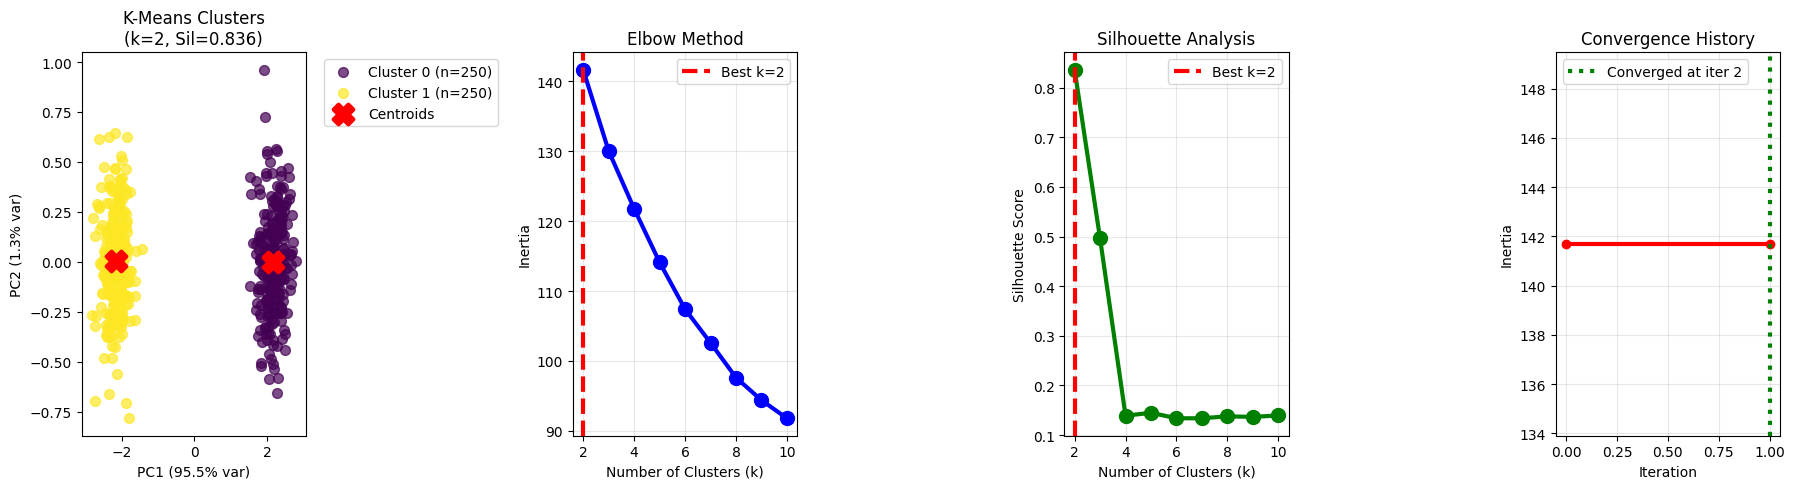


🎯 FINAL MODEL SUMMARY
Best k (Silhouette): 2
Silhouette Score: 0.836
ARI Score: 1.000
Final Inertia: 141.70
Convergence: 2 iterations
Cluster sizes: {0: np.int64(250), 1: np.int64(250)}


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, euclidean_distances, adjusted_rand_score
np.random.seed(42)

# TASK 1: Generate synthetic dataset (500 samples, 5 features, 2 distinct clusters)
n_samples = 500
true_labels = np.array([0]*250 + [1]*250)
X = np.concatenate([np.random.normal([2,2,2,2,2], 0.5, (250,5)),
                    np.random.normal([-2,-2,-2,-2,-2], 0.5, (250,5))])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# TASK 2: Improved K-Means from scratch implementation
class KMeansScratch:
    def __init__(self, n_clusters=5, max_iter=300, random_state=42, init='kmeans++', tol=1e-6):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.init = init
        self.tol = tol
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        self.convergence_iteration_ = None

    def fit(self, X):
        np.random.seed(self.random_state)

        # Initialization
        if self.init == 'kmeans++':
            self.centroids = self._kmeans_plus_plus_init(X)
        else:
            idx = np.random.choice(X.shape[0], self.n_clusters, replace=False)
            self.centroids = X[idx]

        prev_inertia = float('inf')
        inertia_history = []

        for i in range(self.max_iter):
            # Assignment step
            distances = euclidean_distances(X, self.centroids)
            self.labels_ = np.argmin(distances, axis=1)

            # Update step - handle empty clusters
            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                cluster_points = X[self.labels_ == k]
                if len(cluster_points) > 0:
                    new_centroids[k] = cluster_points.mean(axis=0)
                else:
                    # Reinitialize empty cluster to random point
                    new_centroids[k] = X[np.random.choice(X.shape[0])]

            # Calculate inertia with NEW centroids
            current_inertia = np.sum((X - new_centroids[self.labels_])**2)
            inertia_history.append(current_inertia)

            # Convergence check
            if abs(prev_inertia - current_inertia) < self.tol:
                self.convergence_iteration_ = i + 1
                print(f"✓ Converged after {i+1} iterations (inertia change: {abs(prev_inertia - current_inertia):.2e})")
                break

            prev_inertia = current_inertia
            self.centroids = new_centroids
            self.n_iter_ = i + 1

        self.inertia_ = current_inertia
        self.inertia_history_ = np.array(inertia_history)
        return self

    def _kmeans_plus_plus_init(self, X):
        """K-Means++ initialization"""
        centroids = [X[np.random.randint(0, X.shape[0])]]
        for _ in range(1, self.n_clusters):
            # Corrected variable names to avoid NameError
            dists = np.array([min([np.sum((data_point-c_val)**2) for c_val in centroids]) for data_point in X])
            probs = dists / dists.sum()
            centroids.append(X[np.random.choice(X.shape[0], p=probs)])
        return np.array(centroids)

# TASK 3 & 4: Elbow + Silhouette evaluation (3 runs per k)
sil_scores = {k: [] for k in range(2, 11)}
inertias = []
ari_scores = []

print("Evaluating K-Means for k=2 to 10 (3 runs each)...")

for k in range(2, 11):
    run_sil = []
    run_ari = []
    run_inertia = []

    for seed in [42, 123, 456]:
        np.random.seed(seed)
        kmeans = KMeansScratch(n_clusters=k, init='kmeans++')
        kmeans.fit(X_scaled)
        run_sil.append(silhouette_score(X_scaled, kmeans.labels_))
        run_ari.append(adjusted_rand_score(true_labels, kmeans.labels_))
        run_inertia.append(kmeans.inertia_)

    sil_scores[k] = np.mean(run_sil)
    ari_scores.append(np.mean(run_ari))
    inertias.append(np.mean(run_inertia))

best_k_sil = max(range(2, 11), key=lambda k: sil_scores[k])
best_k_ari = max(range(2, 11), key=lambda k: ari_scores[k-2])

print(f"\n🏆 Best k (Silhouette): {best_k_sil} (Score: {sil_scores[best_k_sil]:.3f})")
print(f"🏆 Best k (ARI): {best_k_ari} (Score: {ari_scores[best_k_ari-2]:.3f})")

# TASK 5 & 6: Final model with best k and detailed analysis
print(f"\nRunning final model with k={best_k_sil}...")

np.random.seed(42)
kmeans_final = KMeansScratch(n_clusters=best_k_sil, init='kmeans++')
kmeans_final.fit(X_scaled)

# Detailed results table
results_df = pd.DataFrame({
    'k': range(2, 11),
    'Silhouette': [sil_scores[k] for k in range(2, 11)],
    'ARI': ari_scores,
    'Inertia': inertias
})
results_df['Best_Sil'] = results_df['k'] == best_k_sil
results_df['Best_ARI'] = results_df['k'] == best_k_ari

print("\n📊 Detailed Results Table:")
print(results_df.round(4))

# Cluster statistics
cluster_sizes = pd.Series(kmeans_final.labels_).value_counts().sort_index()
print("\n📈 Cluster Sizes:")
print(cluster_sizes)

# TASK 7: Visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)
cent_2d = pca.transform(kmeans_final.centroids)

plt.figure(figsize=(18, 5))

# 1. Cluster visualization
plt.subplot(1, 4, 1)
colors = plt.cm.viridis(np.linspace(0, 1, best_k_sil))
for i in range(best_k_sil):
    mask = kmeans_final.labels_ == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=[colors[i]], label=f'Cluster {i} (n={np.sum(mask)})',
                alpha=0.7, s=50)
plt.scatter(cent_2d[:, 0], cent_2d[:, 1], c='red', marker='X',
           s=200, linewidths=3, label='Centroids', zorder=5)
plt.title(f'K-Means Clusters\n(k={best_k_sil}, Sil={sil_scores[best_k_sil]:.3f})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Elbow plot
plt.subplot(1, 4, 2)
plt.plot(range(2, 11), inertias, 'bo-', linewidth=3, markersize=10)
plt.axvline(best_k_sil, color='red', linestyle='--', linewidth=3,
           label=f'Best k={best_k_sil}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Silhouette scores
plt.subplot(1, 4, 3)
plt.plot(range(2, 11), [sil_scores[k] for k in range(2, 11)], 'go-', linewidth=3, markersize=10)
plt.axvline(best_k_sil, color='red', linestyle='--', linewidth=3, label=f'Best k={best_k_sil}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Convergence plot
plt.subplot(1, 4, 4)
plt.plot(kmeans_final.inertia_history_, 'r-', linewidth=3, marker='o')
plt.axvline(kmeans_final.convergence_iteration_-1, color='green', linestyle=':', linewidth=3,
           label=f'Converged at iter {kmeans_final.convergence_iteration_}')
plt.xlabel('Iteration')
plt.ylabel('Inertia')
plt.title('Convergence History')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final summary
print("\n" + "="*60)
print("🎯 FINAL MODEL SUMMARY")
print("="*60)
print(f"Best k (Silhouette): {best_k_sil}")
print(f"Silhouette Score: {sil_scores[best_k_sil]:.3f}")
print(f"ARI Score: {adjusted_rand_score(true_labels, kmeans_final.labels_):.3f}")
print(f"Final Inertia: {kmeans_final.inertia_:.2f}")
print(f"Convergence: {kmeans_final.convergence_iteration_} iterations")
print(f"Cluster sizes: {dict(cluster_sizes)}")
print("="*60)